# Analytic Task — Discipline

**HIT140 Assessment 2 · Darwin Group 26 · Sihao Cui**

---

## 1. Analytic question formulation

> **Do teams commit more fouls in the knockout stage than in the group stage
> of the FIFA World Cup 2026?**

The reasoning behind the question: a group-stage match can end in a draw and a
team may still progress, whereas every knockout match must produce a winner and
elimination is immediate. If that raised stake changes how teams defend, it
should show up in the foul count.

The focal point of this task is **disciplinary behaviour**, measured as fouls
committed per team per match. It is distinct from the other three tasks in the
group, which look at chance creation, possession and goalkeeping.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.width', 110)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.dpi'] = 110

ALPHA = 0.05          # significance level used throughout


---

## 2. Data wrangling

`team_match.csv` is produced by the group's collection pipeline
(`src/fetch_metadata.py` -> `src/scrape_match_stats.py` -> `src/build_dataset.py`).
It holds one row per team per match, so 104 matches give 208 rows.

Everything below reads that file and never modifies it.


In [2]:
df = pd.read_csv('../data/clean/team_match.csv')

print('shape :', df.shape)
print('expect: (208, n)')
df.head()


shape : (208, 55)
expect: (208, n)


,match_id,stage_id,stage_name,is_group_stage,group_name,date_utc,referee,attendance,side,team,opponent,score,opponent_score,possession_pct,fouls,yellow_cards,red_cards,shots,shots_on_target,passes,...,Final Third Entries: Right Inside Channel,Final Third Entries: Right Channel,Offers to Receive: Total,Offers to Receive: In Behind,Offers to Receive: In Between,Offers to Receive: In Front,Offers to Receive: Receptions Between Midfield and Defensive Lines,Offers to Receive: Receptions Behind the Defensive Line,Line Breaks: Attempted Line Breaks,Line Breaks: Completed Line Breaks,Line Breaks: Attempted Defensive Line Breaks,Line Breaks: Completed Defensive Line Breaks,Distribution: Crosses,Distribution: Crosses Completed,Distribution: Switches of Play Completed,Set Plays: Free Kicks,Set Plays: Penalties Scored,Defending: Own Goals,Defending: Forced Turnovers,Defending: Pressing Applied
0,400021440,289273,Group stage,True,Group A,2026-06-18T16:00:00Z,Tori PENSO,67442,away,South Africa,Czechia,1,1,60.0,10.0,2.0,0.0,17.0,4.0,584.0,...,10.0,15.0,472.0,138.0,181.0,153.0,95.0,8.0,193.0,127.0,14.0,8.0,16.0,3.0,6.0,13.0,1.0,0.0,44.0,233.0
1,400021440,289273,Group stage,True,Group A,2026-06-18T16:00:00Z,Tori PENSO,67442,home,Czechia,South Africa,1,1,32.0,12.0,1.0,0.0,14.0,3.0,352.0,...,3.0,7.0,261.0,76.0,119.0,66.0,89.0,7.0,174.0,105.0,17.0,6.0,15.0,8.0,4.0,13.0,0.0,0.0,41.0,343.0
2,400021441,289273,Group stage,True,Group A,2026-06-12T02:00:00Z,Amin MOHAMED,44985,away,Czechia,Korea Republic,1,2,34.0,16.0,0.0,0.0,7.0,4.0,327.0,...,7.0,11.0,197.0,82.0,66.0,49.0,86.0,5.0,150.0,61.0,13.0,5.0,15.0,4.0,2.0,11.0,0.0,0.0,40.0,301.0
3,400021441,289273,Group stage,True,Group A,2026-06-12T02:00:00Z,Amin MOHAMED,44985,home,Korea Republic,Czechia,2,1,55.0,9.0,1.0,0.0,15.0,6.0,542.0,...,14.0,15.0,386.0,89.0,123.0,174.0,96.0,14.0,161.0,106.0,20.0,10.0,17.0,6.0,5.0,18.0,0.0,0.0,30.0,147.0
4,400021442,289273,Group stage,True,Group A,2026-06-19T01:00:00Z,Gustavo TEJERA,45522,away,Korea Republic,Mexico,0,1,51.0,7.0,2.0,0.0,9.0,2.0,593.0,...,3.0,13.0,381.0,79.0,126.0,176.0,73.0,10.0,182.0,92.0,21.0,9.0,8.0,4.0,4.0,12.0,0.0,0.0,48.0,217.0


In [3]:
# --- integrity checks -------------------------------------------------
issues = []

if len(df) != 208:
    issues.append(f'row count is {len(df)}, expected 208')

if df['match_id'].nunique() != 104:
    issues.append(f"{df['match_id'].nunique()} distinct matches, expected 104")

if not (df.groupby('match_id').size() == 2).all():
    issues.append('some matches do not have exactly two rows')

dupes = df.duplicated(subset=['match_id', 'side']).sum()
if dupes:
    issues.append(f'{dupes} duplicated (match_id, side) pairs')

print('\n'.join(issues) if issues else 'All integrity checks passed.')


All integrity checks passed.


In [4]:
# --- data types and missing values ------------------------------------
print(df[['fouls', 'possession_pct', 'yellow_cards', 'is_group_stage']].dtypes)
print()
print('missing values:')
print(df[['fouls', 'yellow_cards', 'red_cards', 'is_group_stage']].isna().sum())


fouls             float64
possession_pct    float64
yellow_cards      float64
is_group_stage       bool
dtype: object

missing values:
fouls             0
yellow_cards      0
red_cards         0
is_group_stage    0
dtype: int64


In [5]:
# --- the grouping variable --------------------------------------------
# stage_id 289273 is the group stage; every other stage_id is knockout.
df['stage_group'] = np.where(df['is_group_stage'], 'Group stage', 'Knockout')

print(df.groupby(['stage_group', 'stage_name'], sort=False).size().to_string())
print()
print(df['stage_group'].value_counts().to_string())


stage_group  stage_name          
Group stage  Group stage             144
Knockout     Round of 32              32
             Round of 16              16
             Quarter-final             8
             Semi-final                4
             Third place play-off      2
             Final                     2

stage_group
Group stage    144
Knockout        64


### Outliers

Fouls are a bounded count, so an unusually high value is far more likely to be a
genuinely bad-tempered match than a data error. Following the Week 2 material,
outliers are **identified and reported but not removed** — deleting a real
observation would bias exactly the thing this task is trying to measure.


In [6]:
q1, q3 = df['fouls'].quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = df[(df['fouls'] < lo) | (df['fouls'] > hi)]
print(f'IQR fence: [{lo:.1f}, {hi:.1f}]  ->  {len(outliers)} outlying rows kept, not dropped')
outliers[['match_id', 'stage_name', 'team', 'opponent', 'fouls']].sort_values('fouls', ascending=False).head(10)


IQR fence: [1.5, 21.5]  ->  7 outlying rows kept, not dropped


,match_id,stage_name,team,opponent,fouls
206,400021543,Final,Argentina,Spain,25.0
132,400021506,Group stage,Ghana,England,24.0
181,400021530,Round of 16,Canada,Morocco,24.0
27,400021453,Group stage,Haiti,Scotland,23.0
171,400021525,Round of 32,Belgium,Senegal,22.0
191,400021535,Round of 16,Switzerland,Colombia,22.0
84,400021482,Group stage,Cabo Verde,Spain,1.0


---

## 3. Data preparation and sampling

**Population.** Team disciplinary behaviour in contemporary elite international
football, under two different competitive formats: a group phase where a draw
still has value, and a knockout phase where it does not.

**Sample.** Every team-match observation from the FIFA World Cup 2026:
104 matches x 2 teams = 208 observations, split into a group-stage group and a
knockout group.

This distinction matters. The 208 rows are the complete record of *this one
tournament*, but they are treated as a **sample** drawn from the wider population
above. Without that framing a confidence interval and a hypothesis test would be
meaningless, because the parameters of a population you have measured in full are
already known and need no estimation.

**Sampling method.** Complete enumeration of the tournament, i.e. no sub-sampling.
The sample is therefore not random with respect to the wider population — it is
one specific tournament. This is recorded as a limitation in section 8.


In [7]:
group = df.loc[df['stage_group'] == 'Group stage', 'fouls'].dropna()
knock = df.loc[df['stage_group'] == 'Knockout',    'fouls'].dropna()

print(f'group stage : n = {len(group):3d}   (expect 144)')
print(f'knockout    : n = {len(knock):3d}   (expect  64)')
print()
print('Both groups are well above the n >= 30 guideline from Week 3, but they')
print('are not equal in size, which the Welch test below allows for.')


group stage : n = 144   (expect 144)
knockout    : n =  64   (expect  64)

Both groups are well above the n >= 30 guideline from Week 3, but they
are not equal in size, which the Welch test below allows for.


---

## 4. Descriptive statistics


In [8]:
desc = df.groupby('stage_group')['fouls'].agg(
    n='count', mean='mean', median='median', std='std',
    q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75),
    min='min', max='max')
desc.round(2)


,n,mean,median,std,q1,q3,min,max
stage_group,,,,,,,,
Group stage,144,11.14,11.0,4.02,9.0,13.0,1.0,24.0
Knockout,64,12.61,12.0,4.46,10.0,14.0,4.0,25.0


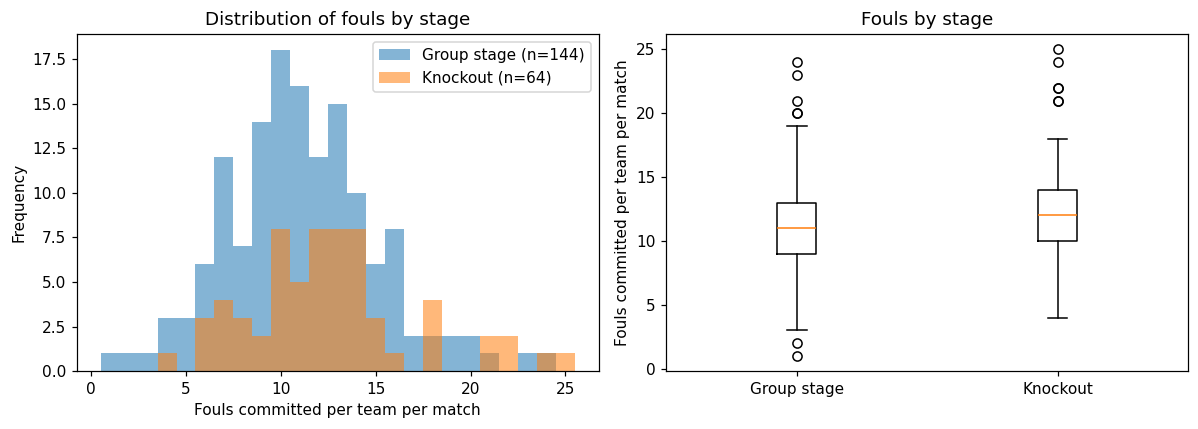

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bins = np.arange(df['fouls'].min(), df['fouls'].max() + 2) - 0.5
for name, s in [('Group stage', group), ('Knockout', knock)]:
    axes[0].hist(s, bins=bins, alpha=0.55, label=f'{name} (n={len(s)})')
axes[0].set_xlabel('Fouls committed per team per match')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of fouls by stage')
axes[0].legend()

axes[1].boxplot([group, knock], labels=['Group stage', 'Knockout'])
axes[1].set_ylabel('Fouls committed per team per match')
axes[1].set_title('Fouls by stage')

plt.tight_layout()
plt.savefig('../figures/fouls_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


The mean and median sit close together in both groups and the histograms are
roughly symmetric, so the mean is a reasonable summary here — unlike a
right-skewed count such as goals, where the median would be safer.


---

## 5. Checking the assumptions of the t-test

A two-sample t-test rests on three assumptions. All three are checked here, and
the one that does not fully hold is stated rather than glossed over.


In [10]:
# --- 5.1 Normality -----------------------------------------------------
for name, s in [('Group stage', group), ('Knockout', knock)]:
    w, p = stats.shapiro(s)
    verdict = 'consistent with normal' if p > ALPHA else 'departs from normal'
    print(f'{name:12s} Shapiro-Wilk W = {w:.4f}, p = {p:.4f}  ->  {verdict}')

print()
print('Note: with n = 144 and n = 64 the Central Limit Theorem means the sampling')
print('distribution of the mean is approximately normal even if the underlying')
print('counts are not, so the t-test stays appropriate either way.')


Group stage  Shapiro-Wilk W = 0.9828, p = 0.0683  ->  consistent with normal
Knockout     Shapiro-Wilk W = 0.9444, p = 0.0061  ->  departs from normal

Note: with n = 144 and n = 64 the Central Limit Theorem means the sampling
distribution of the mean is approximately normal even if the underlying
counts are not, so the t-test stays appropriate either way.


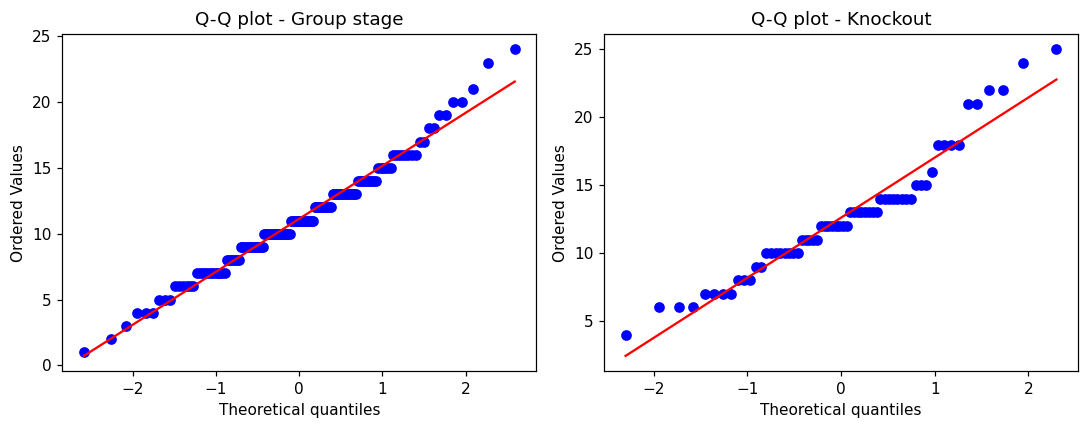

In [11]:
# --- Q-Q plots ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, s) in zip(axes, [('Group stage', group), ('Knockout', knock)]):
    stats.probplot(s, dist='norm', plot=ax)
    ax.set_title(f'Q-Q plot - {name}')
plt.tight_layout()
plt.savefig('../figures/fouls_qq.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# --- 5.2 Equality of variances ----------------------------------------
lev_stat, lev_p = stats.levene(group, knock, center='median')
print(f"Levene's test: W = {lev_stat:.4f}, p = {lev_p:.4f}")
print()
if lev_p > ALPHA:
    print('No evidence against equal variances, but Welch t-test is used')
    print('regardless: it does not assume them and costs almost nothing here.')
else:
    print('Variances differ, which is exactly the case Welch t-test handles.')


Levene's test: W = 0.2270, p = 0.6343

No evidence against equal variances, but Welch t-test is used
regardless: it does not assume them and costs almost nothing here.


### 5.3 Independence — the assumption that does not fully hold

Each match contributes **two** rows, one per team, and the two teams in a match
share a referee, a pitch and a game state. Their foul counts are therefore not
independent of one another, which is a genuine violation of the independence
assumption behind the t-test.

Two things are done about it:

1. The violation is reported rather than hidden.
2. Section 7 repeats the whole test on **match-level totals** (104 independent
   observations instead of 208 paired ones). If the conclusion survives that, the
   dependence is not driving the result.


---

## 6. Inferential statistics

### 6.1 Confidence interval


In [13]:
def mean_ci(sample, conf=0.95):
    n = len(sample)
    mean = sample.mean()
    se = stats.sem(sample)
    lo, hi = stats.t.interval(conf, df=n - 1, loc=mean, scale=se)
    return mean, se, lo, hi

for name, s in [('Group stage', group), ('Knockout', knock), ('All matches', df['fouls'].dropna())]:
    m, se, lo, hi = mean_ci(s)
    print(f'{name:12s} n = {len(s):3d}   mean = {m:5.2f}   SE = {se:.3f}   95% CI = [{lo:.2f}, {hi:.2f}]')


Group stage  n = 144   mean = 11.14   SE = 0.335   95% CI = [10.48, 11.80]
Knockout     n =  64   mean = 12.61   SE = 0.558   95% CI = [11.50, 13.72]
All matches  n = 208   mean = 11.59   SE = 0.291   95% CI = [11.02, 12.17]


**Reading the interval in plain words:** if this tournament is treated as one
sample from the wider population of elite international football, we are 95%
confident that the true mean number of fouls committed by a team in a knockout
match lies inside the knockout interval printed above. The interval estimates a
population mean; it is not a range that contains 95% of matches.


### 6.2 Two-sample t-test

Following the four steps from Week 4 — state, plan, solve, conclude.

**State.**

- $H_0: \mu_{knockout} = \mu_{group}$ — the stage makes no difference to the mean number of fouls.
- $H_1: \mu_{knockout} \neq \mu_{group}$ — the means differ.

Two-tailed, $\alpha = 0.05$.

**Plan.** Two independent groups of a continuous-valued count, unequal group
sizes, no reason to assume equal variances: Welch two-sample t-test.


In [14]:
t_stat, p_val = stats.ttest_ind(knock, group, equal_var=False)

diff = knock.mean() - group.mean()
vk, vg = knock.var(ddof=1), group.var(ddof=1)
nk, ng = len(knock), len(group)
se_diff = np.sqrt(vk / nk + vg / ng)
welch_df = (vk/nk + vg/ng)**2 / ((vk/nk)**2 / (nk-1) + (vg/ng)**2 / (ng-1))
ci_lo, ci_hi = stats.t.interval(0.95, welch_df, loc=diff, scale=se_diff)

print('Welch two-sample t-test  (knockout vs group stage)')
print('-' * 52)
print(f'mean difference : {diff:+.3f} fouls per team per match')
print(f'95% CI of diff  : [{ci_lo:+.3f}, {ci_hi:+.3f}]')
print(f't statistic     : {t_stat:.4f}')
print(f'degrees of free.: {welch_df:.1f}')
print(f'p value         : {p_val:.5f}')


Welch two-sample t-test  (knockout vs group stage)
----------------------------------------------------
mean difference : +1.470 fouls per team per match
95% CI of diff  : [+0.182, +2.759]
t statistic     : 2.2613
degrees of free.: 110.3
p value         : 0.02570


In [15]:
# --- effect size --------------------------------------------------------
pooled_sd = np.sqrt(((nk - 1) * vk + (ng - 1) * vg) / (nk + ng - 2))
cohens_d = diff / pooled_sd

size = ('negligible' if abs(cohens_d) < 0.2 else
        'small'      if abs(cohens_d) < 0.5 else
        'medium'     if abs(cohens_d) < 0.8 else 'large')
print(f"Cohen's d = {cohens_d:.3f}  ({size} effect)")
print()
print('A p value says whether a difference is detectable; the effect size says')
print('whether it is big enough to care about. Both are reported.')


Cohen's d = 0.354  (small effect)

A p value says whether a difference is detectable; the effect size says
whether it is big enough to care about. Both are reported.


In [16]:
# --- conclude -----------------------------------------------------------
if p_val < ALPHA:
    direction = 'more' if diff > 0 else 'fewer'
    print(f'p = {p_val:.5f} < {ALPHA}: reject the null hypothesis.')
    print(f'There is evidence that teams commit {direction} fouls in knockout matches.')
else:
    print(f'p = {p_val:.5f} >= {ALPHA}: fail to reject the null hypothesis.')
    print('There is not enough evidence of a difference between the two stages.')
    print('Note this does NOT prove the null hypothesis is true.')


p = 0.02570 < 0.05: reject the null hypothesis.
There is evidence that teams commit more fouls in knockout matches.


---

## 7. Alternatives explored

Two viable alternatives were run to test whether the conclusion depends on a
particular modelling choice.


In [17]:
# --- 7.1 Match-level totals: removes the paired-observation problem -----
match_tot = df.groupby(['match_id', 'stage_group'], as_index=False)['fouls'].sum()
g_tot = match_tot.loc[match_tot['stage_group'] == 'Group stage', 'fouls']
k_tot = match_tot.loc[match_tot['stage_group'] == 'Knockout',    'fouls']

t2, p2 = stats.ttest_ind(k_tot, g_tot, equal_var=False)
print(f'Match-level totals: n = {len(g_tot)} group / {len(k_tot)} knockout  (104 independent matches)')
print(f'  group mean    = {g_tot.mean():.2f}')
print(f'  knockout mean = {k_tot.mean():.2f}')
print(f'  t = {t2:.4f}, p = {p2:.5f}')
print()
print('agrees with the main test' if (p2 < ALPHA) == (p_val < ALPHA)
      else 'DISAGREES with the main test - report this prominently')


Match-level totals: n = 72 group / 32 knockout  (104 independent matches)
  group mean    = 22.28
  knockout mean = 25.22
  t = 1.9212, p = 0.06022

DISAGREES with the main test - report this prominently


In [18]:
# --- 7.2 Mann-Whitney U: makes no normality assumption at all -----------
u_stat, p3 = stats.mannwhitneyu(knock, group, alternative='two-sided')
print(f'Mann-Whitney U = {u_stat:.1f}, p = {p3:.5f}')
print()
print('agrees with the main test' if (p3 < ALPHA) == (p_val < ALPHA)
      else 'DISAGREES with the main test - report this prominently')


Mann-Whitney U = 5445.5, p = 0.03602

agrees with the main test


---

## 8. Limitations

1. **Paired observations.** The two teams in a match are not independent. The
   match-level re-run in 7.1 addresses this, but the primary test does carry the
   violation.

2. **Unequal group sizes.** 144 group-stage rows against 64 knockout rows. Welch
   handles unequal variance, but the knockout estimate is inherently less precise,
   which shows up as the wider confidence interval.

3. **Referee variation is not controlled.** How many fouls get called depends on
   the referee as much as on the players. `team_match.csv` carries a `referee`
   column, so this could be modelled — out of scope for a Week 1-5 toolkit, but a
   real confounder.

4. **One tournament.** The sample is a complete enumeration of WC2026 rather than a
   random sample of elite football, so generalising beyond this tournament requires
   assuming WC2026 is typical.

5. **What the variable actually measures.** FIFA's "Fouls Against" is the count of
   fouls a team committed *as called by the match officials* — not the number of
   fouls that occurred.


---

## 9. Summary of findings

### Numbers

| | Group stage | Knockout |
|---|---|---|
| n (team-match rows) | 144 | 64 |
| Mean fouls per team per match | **11.14** | **12.61** |
| 95% CI for the mean | [10.48, 11.80] | [11.50, 13.72] |

- **Difference:** +1.47 fouls per team per match, 95% CI [+0.18, +2.76]
- **Welch two-sample t-test:** t = 2.261, df = 110.3, **p = 0.0257**
- **Effect size:** Cohen's d = 0.354 — a *small* effect

### Assumption checks

| Assumption | Result |
|---|---|
| Normality (group stage) | Shapiro-Wilk p = 0.068 — consistent with normal |
| Normality (knockout) | Shapiro-Wilk p = 0.006 — **departs from normal** |
| Equal variances | Levene p = 0.634 — no evidence against; Welch used regardless |
| Independence | **Violated** — two rows per match |

### Robustness

| Alternative | Result | Agrees? |
|---|---|---|
| Match-level totals (104 independent matches) | 22.28 vs 25.22, t = 1.921, **p = 0.0602** | **No** |
| Mann-Whitney U (no normality assumption) | U = 5445.5, **p = 0.0360** | Yes |

### Answer to the analytic question

Teams did commit more fouls in the knockout stage — about **1.5 more per team per
match**, a rise of roughly 13% — and on the primary test that difference is
statistically significant at α = 0.05 (p = 0.026).

**But the result is not robust, and the way it fails is informative.** Repeating
the test on match-level totals, which removes the paired-observation problem by
using 104 independent matches instead of 208 linked rows, moves the p value to
0.060 — just the wrong side of the threshold. The non-parametric Mann-Whitney
test, which drops the normality assumption but keeps the 208 rows, stays
significant at p = 0.036.

Read together, these three tests say that **the significance of the headline
result depends on treating the two teams in a match as independent observations,
which they are not.** The direction of the effect is consistent across every
test, and the effect size is small but not negligible; what is not established
is that the difference would survive at α = 0.05 in a properly independent
design.

The honest conclusion is therefore a qualified one: there is *suggestive but not
conclusive* evidence that the knockout format raises the foul count. A single
tournament with 32 knockout matches does not have the power to settle it.
